Libraries

In [218]:
import pandas as pd
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

Read in CellPhoneDB data

In [11]:
CellPhoneDB_relevant_interactions = pd.read_csv('CellPhoneDb/Network/degs_analysis_relevant_interactions_03_03_2025_224407.txt', sep ='\t')

In [30]:
CellPhoneDB_filtered = CellPhoneDB_relevant_interactions.loc[:, ['interacting_pair'] + list(CellPhoneDB_relevant_interactions.columns[14:])]

In [58]:
CellPhoneDB_filtered_indexed = CellPhoneDB_filtered.set_index('interacting_pair')


In [59]:
model = KMeans(30)   
model = model.fit(CellPhoneDB_filtered_indexed)

In [60]:
CellPhoneDB_filtered_indexed['Cluster'] = model.predict(CellPhoneDB_filtered_indexed)

In [61]:
data_for_pca = CellPhoneDB_filtered_indexed.drop(columns=['Cluster'])


In [84]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_for_pca)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['interacting_pair'] = CellPhoneDB_filtered['interacting_pair']
pca_df['Cluster'] =  CellPhoneDB_filtered_indexed['Cluster'].reset_index()['Cluster']
pca_df['Cluster'] = pd.Categorical(pca_df['Cluster'])


<Axes: xlabel='PC1', ylabel='PC2'>

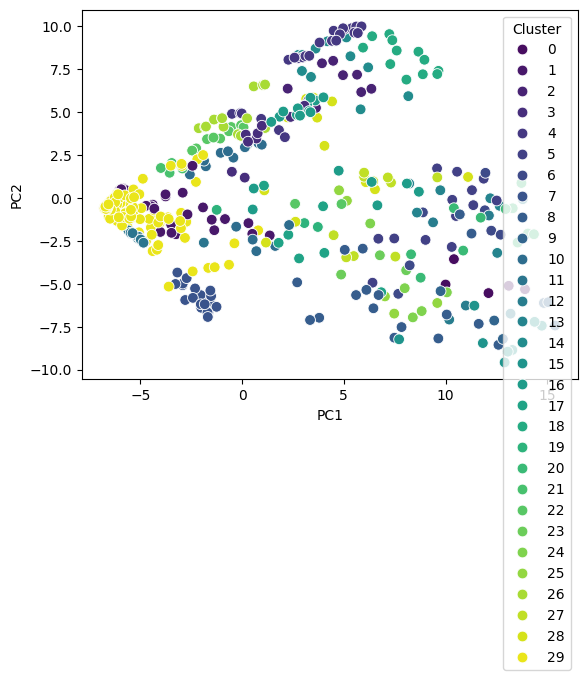

In [85]:
sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue = 'Cluster', palette='viridis', s=60)


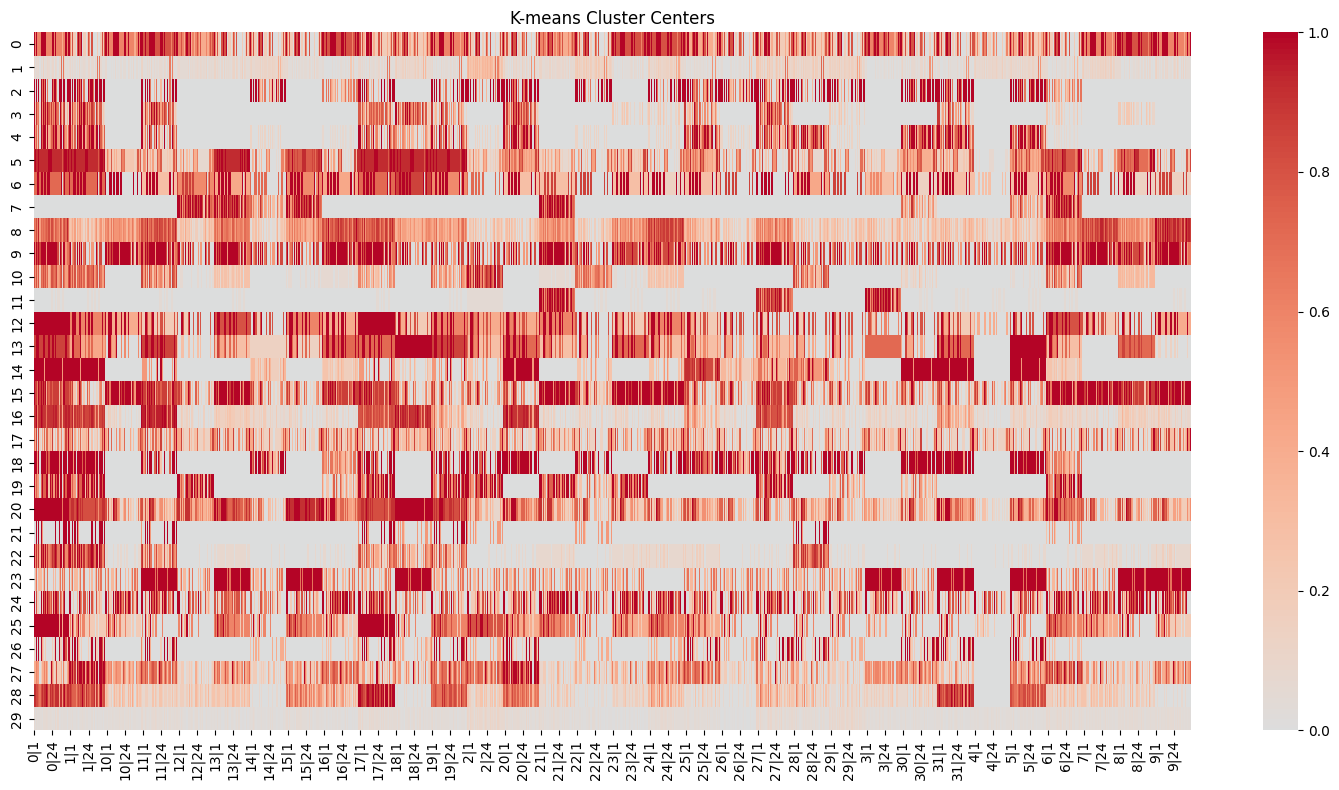

In [90]:
centers = model.cluster_centers_
centers_df = pd.DataFrame(centers, columns=CellPhoneDB_filtered_indexed.drop(columns=['Cluster']).columns)

plt.figure(figsize=(15, 8))
sns.heatmap(centers_df, cmap='coolwarm', center=0, annot=False)
plt.title('K-means Cluster Centers')
plt.tight_layout()
plt.show()

In [96]:
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(CellPhoneDB_filtered_indexed.drop(columns=['Cluster']))

# Create dataframe for plotting
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cluster'] = CellPhoneDB_filtered_indexed['Cluster'].reset_index()['Cluster']
umap_df['interacting_pair'] = CellPhoneDB_filtered['interacting_pair']



c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


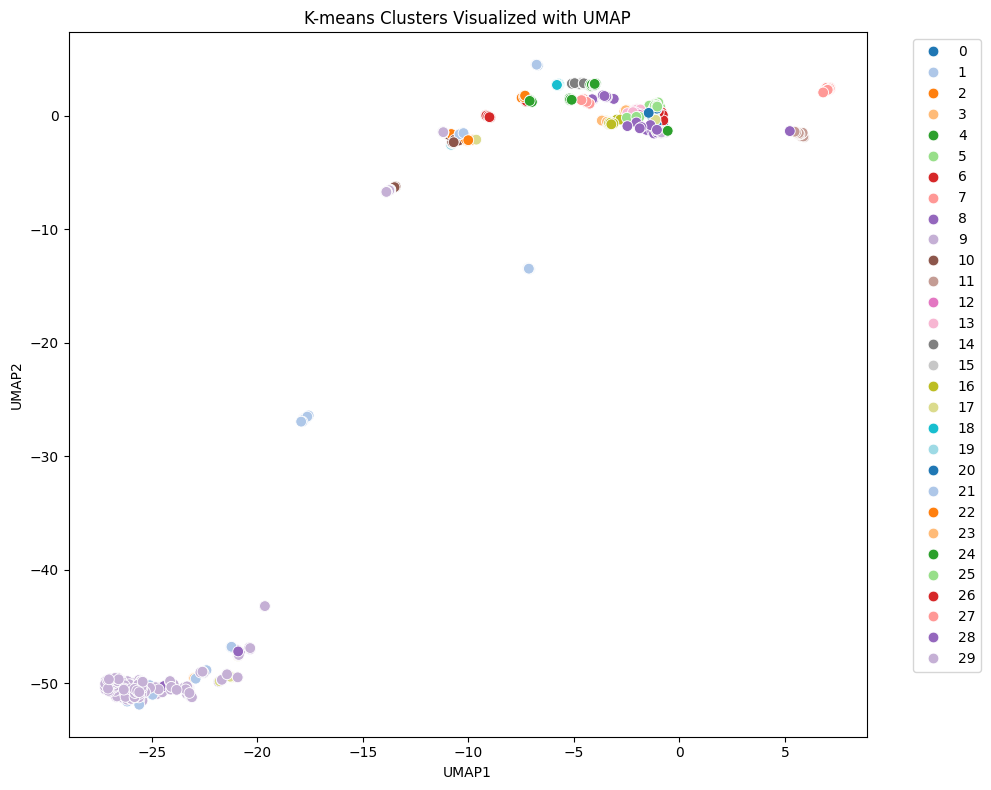

In [97]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', data=umap_df, palette='tab20', s=60)
plt.title('K-means Clusters Visualized with UMAP')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Alright so what ive done is cluster based on the ligand receptor pairs, cluster 29 seems off in another universe

In [101]:
cluster_29 = umap_df.interacting_pair[umap_df.Cluster == 29]

Doesnt seem to be any consistent theme for cluster 29 

In [103]:
umap_df['Cluster'].value_counts()

Cluster
29    190
1      41
4      24
11     21
16     20
7      20
8      17
26     15
10     15
5      13
18     12
14     12
28     12
22     12
20     11
27     10
2       9
3       9
15      8
13      7
6       7
17      7
9       6
25      5
12      5
0       5
24      5
19      4
21      4
23      3
Name: count, dtype: int64

It might just be that cluster 29 is some slop

Clustering based on cluster-cluster pair

In [163]:
CellPhoneDB_filtered = CellPhoneDB_relevant_interactions.loc[:, list(CellPhoneDB_relevant_interactions.columns[14:])]

In [173]:
CellPhoneDB_transposed = CellPhoneDB_filtered.transpose()
CellPhoneDB_transposed =CellPhoneDB_transposed

In [175]:
CellPhoneDB_transposed_numeric = CellPhoneDB_transposed

In [176]:
model_clusters = KMeans(30)   
model_clusters = model_clusters.fit(CellPhoneDB_transposed_numeric)

In [177]:
reducer_clusters = umap.UMAP(random_state=42)
umap_result = reducer_clusters.fit_transform(CellPhoneDB_transposed_numeric)

c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [183]:
# Create dataframe for plotting
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['cluster_pair'] = CellPhoneDB_filtered.columns
umap_df['Cluster'] = model_clusters.predict(CellPhoneDB_transposed_numeric)

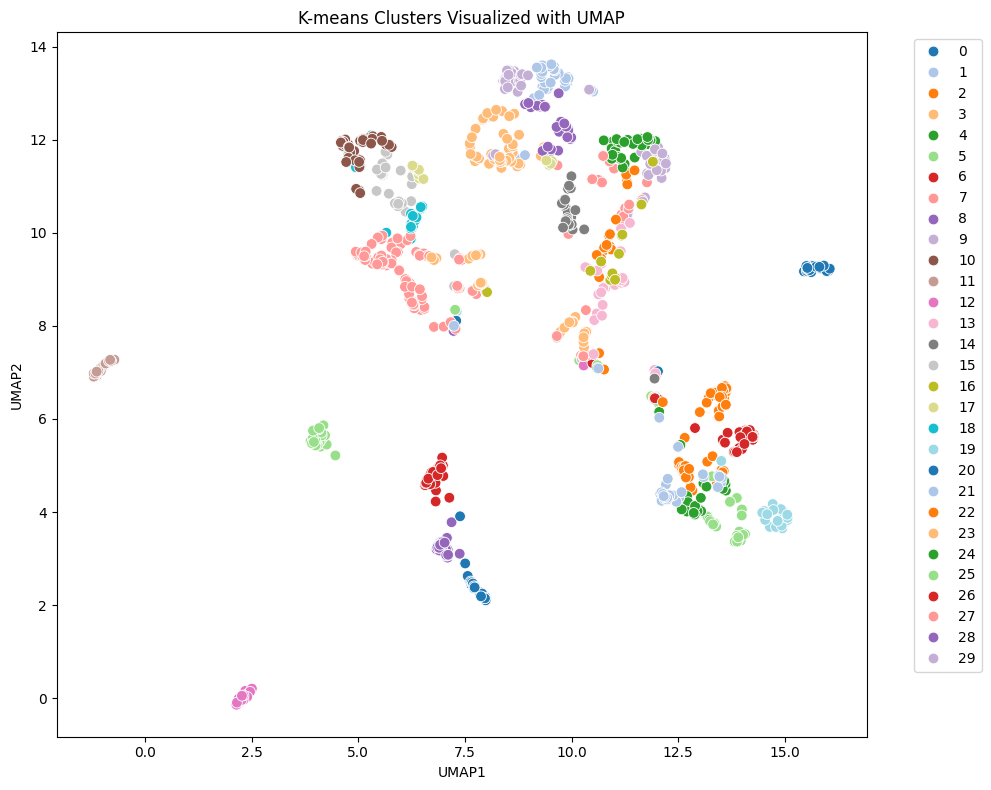

In [184]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', data=umap_df, palette='tab20', s=60)
plt.title('K-means Clusters Visualized with UMAP')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [185]:
umap_df['Cluster'].value_counts()

Cluster
7     106
2      59
3      50
10     44
1      41
4      38
9      36
26     34
18     33
24     32
8      32
19     31
11     31
0      31
6      31
5      31
21     31
15     30
12     30
20     30
25     29
28     28
14     28
23     28
13     28
29     28
27     21
22     20
17     19
16     13
Name: count, dtype: int64

In [ ]:
cluster_7 = umap_df['cluster_pair'][umap_df['Cluster']==7]
split_pairs_7 = cluster_7.str.split('|')

split_df_7 = split_pairs_7.apply(pd.Series)
split_df_7.columns = ['Sender', 'Receiver']


In [201]:
split_df_7['Sender'].value_counts()

Sender
4     32
26    10
22    10
29    10
14     5
27     3
23     2
30     2
25     2
10     2
21     2
28     2
2      2
7      2
8      2
12     2
11     2
5      1
6      1
3      1
31     1
1      1
24     1
20     1
19     1
18     1
17     1
16     1
15     1
13     1
9      1
Name: count, dtype: int64

In [202]:
split_df_7['Receiver'].value_counts()

Receiver
4     31
3     13
14    10
12     5
8      5
21     4
26     4
28     4
29     4
30     4
27     1
23     1
24     1
25     1
7      1
31     1
5      1
6      1
20     1
22     1
16     1
2      1
19     1
18     1
17     1
15     1
13     1
11     1
10     1
1      1
0      1
9      1
Name: count, dtype: int64

Seems like 7 is interactions with oligodendrocytes

In [203]:
cluster_4 = umap_df['cluster_pair'][umap_df['Cluster']==4]
split_pairs_4 = cluster_4.str.split('|')

split_df_4 = split_pairs_4.apply(pd.Series)
split_df_4.columns = ['Sender', 'Receiver']

In [204]:
split_df_4['Sender'].value_counts()

Sender
11    9
0     8
17    8
1     7
19    6
Name: count, dtype: int64

In [205]:
split_df_4['Receiver'].value_counts()

Receiver
11    5
13    5
15    5
27    5
5     5
6     5
9     3
0     2
16    2
3     1
Name: count, dtype: int64

Not clear what to make of this, I guess POA sends?

In [207]:
cluster_2 = umap_df['cluster_pair'][umap_df['Cluster']==2]
split_pairs_2 = cluster_2.str.split('|')

split_df_2 = split_pairs_2.apply(pd.Series)
split_df_2.columns = ['Sender', 'Receiver']

In [208]:
split_df_2['Sender'].value_counts()

Sender
8     30
10    29
Name: count, dtype: int64

In [209]:
split_df_2['Receiver'].value_counts()

Receiver
0     2
1     2
9     2
8     2
7     2
6     2
5     2
31    2
30    2
29    2
28    2
27    2
26    2
25    2
24    2
23    2
22    2
21    2
20    2
2     2
19    2
17    2
16    2
15    2
14    2
13    2
12    2
11    2
10    2
18    1
Name: count, dtype: int64

No idea what to make of that but that's cool

In [216]:
data = []
for i in umap_df['Cluster']:
    cluster_pairs = umap_df['cluster_pair'][umap_df['Cluster']==i]
    split_pairs = cluster_pairs.str.split('|')
    split_pairs = split_pairs.apply(pd.Series)
    split_pairs.columns = ['Sender', 'Receiver']
    split_pairs['Pair'] = cluster_pairs
    split_pairs['Cluster'] = i

    data.append(split_pairs)


In [217]:
cluster_pairs_aggregated = pd.concat(data, ignore_index=True)

Perform fisher's exact test

Ok let me think about how I want to do this:
for each k-means cluster, I want to ask which clusters are enriched as senders and receivers. To do this, I think I do a nested for loop where the first loop is the k-means cluster, the second test if it's enriched as a sender by making a contingency table where 

                                                                        ['number of sends in cluster', 'other sends in cluster',

                                                                        'number of sends in other clusters', 'other sends in other clusters]

In [ ]:
for i in cluster_pairs_aggregated.Cluster.unique():
    subset_df = cluster_pairs_aggregated[cluster_pairs_aggregated['Cluster']==i]
    anti_subset_df = cluster_pairs_aggregated[cluster_pairs_aggregated['Cluster']!=i]
    

In [221]:
cluster_pairs_aggregated.Cluster.value_counts()

Cluster
7     11236
2      3481
3      2500
10     1936
1      1681
4      1444
9      1296
26     1156
18     1089
24     1024
8      1024
19      961
11      961
0       961
6       961
5       961
21      961
15      900
12      900
20      900
25      841
28      784
14      784
23      784
13      784
29      784
27      441
22      400
17      361
16      169
Name: count, dtype: int64

I think I'll pick this up tomorrow, I think value counts is the way to do this